<a href="https://colab.research.google.com/github/DarkRai476/abcd/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WATER JUG PROBLEM
Jug A capacity = 4 litres
Jug B capacity = 3 litres
Goal = Exactly 2 litres

Minimum number of operations: 4

Step 0: (0, 0) - Both jugs are empty
Step 1: (0, 3) - Fill Jug B
Step 2: (3, 0) - Pour Jug B into Jug A
Step 3: (3, 3) - Fill Jug B
Step 4: (4, 2) - Pour Jug B into Jug A

PICTURES OF EACH STEP


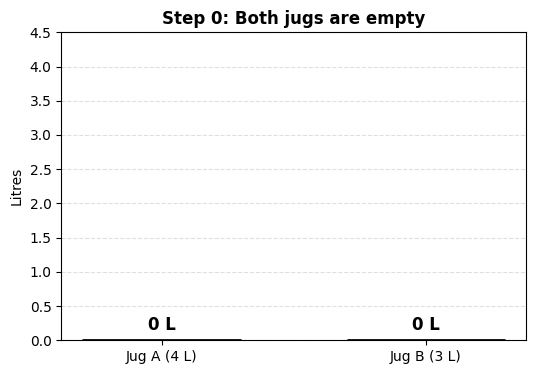

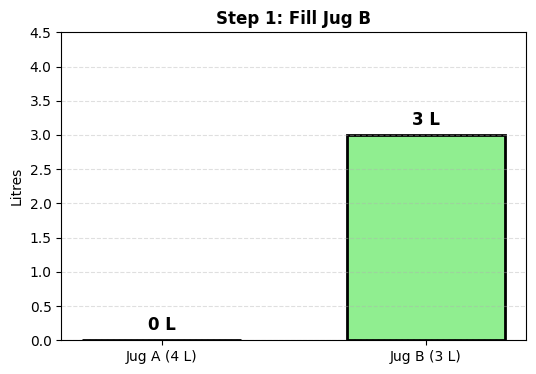

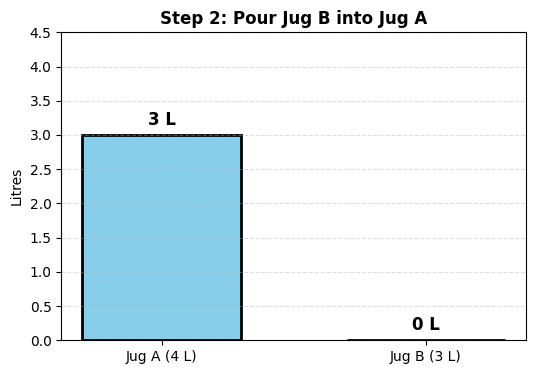

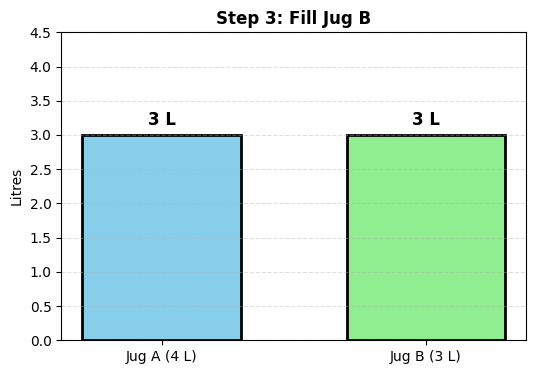

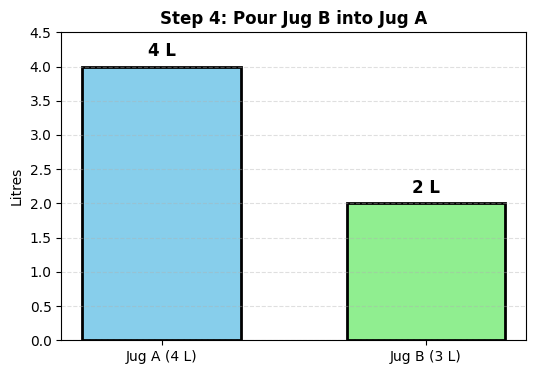

In [ ]:
from collections import deque
import matplotlib.pyplot as plt

# Jug capacities
CAP_A = 4
CAP_B = 3

# Starting state
start = (0, 0)

# Goal
goal = 2


# -------------------------------------------------
# Function to draw the two jugs
# -------------------------------------------------

def draw_jugs(state, step, operation):
    a, b = state

    fig, ax = plt.subplots(figsize=(6, 4))

    # Draw Jug A
    ax.bar(1, a, width=0.6, color="skyblue",
           edgecolor="black", linewidth=2)

    # Draw Jug B
    ax.bar(2, b, width=0.6, color="lightgreen",
           edgecolor="black", linewidth=2)

    # Labels
    ax.text(1, a + 0.15, f"{a} L",
            ha="center", fontsize=12, fontweight="bold")

    ax.text(2, b + 0.15, f"{b} L",
            ha="center", fontsize=12, fontweight="bold")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Jug A (4 L)", "Jug B (3 L)"])

    ax.set_ylim(0, 4.5)
    ax.set_ylabel("Litres")

    ax.set_title(f"Step {step}: {operation}",
                 fontsize=12, fontweight="bold")

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()


# -------------------------------------------------
# BFS
# -------------------------------------------------

queue = deque([start])

visited = {start}

parent = {}
action = {}

goal_state = None

while queue:

    current = queue.popleft()
    x, y = current

    # Check goal
    if x == goal or y == goal:
        goal_state = current
        break

    # Possible operations

    states = []

    # 1. Fill Jug A
    states.append(
        ((CAP_A, y), "Fill Jug A")
    )

    # 2. Fill Jug B
    states.append(
        ((x, CAP_B), "Fill Jug B")
    )

    # 3. Empty Jug A
    states.append(
        ((0, y), "Empty Jug A")
    )

    # 4. Empty Jug B
    states.append(
        ((x, 0), "Empty Jug B")
    )

    # 5. Pour A -> B
    amount = min(x, CAP_B - y)

    states.append(
        ((x - amount, y + amount),
         "Pour Jug A into Jug B")
    )

    # 6. Pour B -> A
    amount = min(y, CAP_A - x)

    states.append(
        ((x + amount, y - amount),
         "Pour Jug B into Jug A")
    )

    # Add states to BFS queue
    for new_state, operation in states:

        if new_state not in visited:

            visited.add(new_state)

            queue.append(new_state)

            parent[new_state] = current
            action[new_state] = operation


# -------------------------------------------------
# Create solution path
# -------------------------------------------------

path = []

state = goal_state

while state != start:

    path.append(
        (state, action[state])
    )

    state = parent[state]

path.reverse()


# -------------------------------------------------
# Print solution
# -------------------------------------------------

print("WATER JUG PROBLEM")
print("=" * 40)

print("Jug A capacity = 4 litres")
print("Jug B capacity = 3 litres")
print("Goal = Exactly 2 litres")
print()

print("Minimum number of operations:", len(path))
print()

print("Step 0: (0, 0) - Both jugs are empty")

for i, (state, operation) in enumerate(path, 1):

    print(
        f"Step {i}: {state} - {operation}"
    )


# -------------------------------------------------
# Display pictures
# -------------------------------------------------

print("\nPICTURES OF EACH STEP")
print("=" * 40)

# Starting state
draw_jugs(
    start,
    0,
    "Both jugs are empty"
)

# Every solution step
for i, (state, operation) in enumerate(path, 1):

    draw_jugs(
        state,
        i,
        operation
    )